# CPE393: Final Group Project — Sport and Health: Predicting Fitness Level from Daily Activity and Lifestyle Data

**Group:** IUTO
**Members:** Leni Chabilan | Romain Mechain | Kylian Riberou
**Course:** CPE393 — Introduction to Data Science with Python, Summer 2026, KMUTT

**Project type:** Regression

This notebook predicts a continuous daily **fitness score** (`fitness_level`, range 0–22) from everyday activity and lifestyle indicators (exercise duration, intensity, steps, sleep, stress, hydration) collected from 3,000 participants over 687,701 daily records in 2024. We follow the full workflow required by the course guidelines: problem definition, data cleaning, EDA, visualization, feature engineering, model training (3 regression models), evaluation, and a Responsible AI discussion.

## 0. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Fixed random state for reproducibility (per project requirements)
RANDOM_STATE = 42

os.makedirs("figures", exist_ok=True)
pd.set_option("display.max_columns", 30)

## 1. Problem Definition

**Problem statement:** Fitness is shaped by many everyday habits at once — exercise frequency, duration and intensity, daily step count, sleep, stress, and hydration — but the combined effect of these factors is rarely made visible in a simple, data-driven way. This project asks: **which lifestyle and activity factors most influence a person's fitness level, and how accurately can we predict that fitness level from daily habits alone?**

**Motivation:** Wearable devices and health apps now collect this kind of daily data at scale. Understanding which everyday habits actually move the needle on fitness (as opposed to habits that *feel* important but show little real effect) has practical value for personal health coaching, app design, and public-health communication — provided the conclusions are reported honestly rather than overstated.

**Target variable:** `fitness_level` — a continuous daily fitness score (observed range ≈ 0–22 in this dataset). This is a **regression** problem.

**Expected outcome:** Based on domain intuition, we expect exercise duration, intensity, and step count to be the strongest predictors. We anticipate **moderate** predictive performance rather than a perfect model, since a single fitness score cannot capture every aspect of a person's real-world health and situation (stressful work, environment, genetics, etc.). As required by the course's Responsible AI policy, we report whether the data actually support this hypothesis — including when they do not.

## 2. Dataset Description

- **Source:** Public health & fitness dataset (CSV), provided as `data/health_fitness_dataset.csv`.
  ⚠️ **Action needed from the group:** we could not verify an exact, citable Kaggle (or other) listing URL for this exact file from its column structure alone. Please paste the **exact dataset URL and license/usage terms** here (and in `data/data_link.txt` / `README.md`) before submission — the guidelines explicitly require reporting the source URL and license, and we should never guess or invent one.
- **Description:** Daily wearable/health-tracking records for a cohort of participants, combining daily activity logs (exercise type, duration, intensity, calories, heart rate, steps) with slower-changing health and demographic attributes (age, gender, height, BMI, resting heart rate, blood pressure, smoking status, diagnosed health conditions).
- **Number of rows:** 687,701 daily records.
- **Number of columns:** 22.
- **Number of unique participants:** 3,000 (≈198–261 records per participant, i.e. roughly 7–9 months of near-daily tracking each, across the period 2024-01-01 to 2024-12-25).
- **Target variable:** `fitness_level` (continuous, regression).
- **File format:** CSV, one row per participant per tracked day.
- **Key limitations identified up front (expanded in Section 10):**
  - The dataset is very likely **simulated/synthetic** rather than collected from real devices — several variables follow suspiciously deterministic patterns (see Section 4.6 and 8.2). This matters for how strongly we can trust any conclusion as "real-world."
  - `health_condition` is mostly empty (no diagnosed condition), which is normal, not a data quality problem.
  - Static attributes (age, height, BMI, resting heart rate, blood pressure, gender, smoking status) are recorded identically on every row for a given participant — they describe the person, not the day.

In [2]:
# Load dataset
df = pd.read_csv("data/health_fitness_dataset.csv", parse_dates=["date"])
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [3]:
# Basic structural overview
print("Shape:", df.shape)
df.info()

Shape: (687701, 22)
<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   participant_id            687701 non-null  int64         
 1   date                      687701 non-null  datetime64[us]
 2   age                       687701 non-null  int64         
 3   gender                    687701 non-null  str           
 4   height_cm                 687701 non-null  float64       
 5   weight_kg                 687701 non-null  float64       
 6   activity_type             687701 non-null  str           
 7   duration_minutes          687701 non-null  int64         
 8   intensity                 687701 non-null  str           
 9   calories_burned           687701 non-null  float64       
 10  avg_heart_rate            687701 non-null  int64         
 11  hours_sleep               687701 non-null  float64      

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
participant_id,687701.0,NaN,NaN,NaN,1499.781828,1.0,749.0,1499.0,2249.0,3000.0,865.997215
date,687701,NaN,NaN,NaN,2024-06-16 18:44:21.629981,2024-01-01 00:00:00,2024-03-21 00:00:00,2024-06-06 00:00:00,2024-09-11 00:00:00,2024-12-25 00:00:00,NaN
age,687701.0,NaN,NaN,NaN,41.658602,18.0,30.0,42.0,53.0,64.0,13.58177
gender,687701,3,F,338856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,687701.0,NaN,NaN,NaN,168.587699,145.0,161.7,168.2,175.3,198.5,9.140811
weight_kg,687701.0,NaN,NaN,NaN,94.921981,45.3,78.2,94.6,110.5,188.4,22.461801
activity_type,687701,10,Yoga,69961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_minutes,687701.0,NaN,NaN,NaN,70.011671,20.0,45.0,70.0,95.0,120.0,29.147251
intensity,687701,3,Medium,343433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories_burned,687701.0,NaN,NaN,NaN,15.381302,0.8,7.8,13.0,20.7,92.0,9.985552


## 3. Preprocessing and Cleaning

Document every decision made below (why a column was dropped, how missing values were handled, etc.) — this is graded explicitly.

### 3.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

health_condition    490275
dtype: int64

**Decision:** `health_condition` is the only column with missing values (490,275 / 687,701 ≈ 71.3%). After inspection, the missing values are **not random data-collection gaps** — `NaN` here simply means *no diagnosed condition was reported* for that participant, alongside the three diagnosed categories `Diabetes`, `Hypertension`, and `Asthma`. Dropping these rows or imputing a fake diagnosis would be incorrect; instead we recode `NaN` to an explicit `"None"` category, which is also safer for the Responsible AI discussion (Section 10) since it keeps the absence of a diagnosis visible and auditable rather than hidden inside a generic "missing" bucket.

In [6]:
df["health_condition"] = df["health_condition"].fillna("None")
df["health_condition"].value_counts(dropna=False)

health_condition
None            490275
Hypertension     99437
Diabetes         64754
Asthma           33235
Name: count, dtype: int64

### 3.2 Duplicates

In [7]:
n_dupes = df.duplicated().sum()
print("Fully duplicated rows:", n_dupes)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Fully duplicated rows: 0


Shape after dropping duplicates: (687701, 22)


**Decision:** No fully duplicated rows were found. The `drop_duplicates()` call is kept anyway as a safety net for reproducibility if the raw file is regenerated or re-exported.

### 3.3 Data Types and Inconsistent Formats

In [8]:
df.dtypes

participant_id                       int64
date                        datetime64[us]
age                                  int64
gender                                 str
height_cm                          float64
weight_kg                          float64
activity_type                          str
duration_minutes                     int64
intensity                              str
calories_burned                    float64
avg_heart_rate                       int64
hours_sleep                        float64
stress_level                         int64
daily_steps                          int64
hydration_level                    float64
bmi                                float64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
health_condition                       str
smoking_status                         str
fitness_level                      float64
dtype: object

In [9]:
# `date` was already parsed as datetime at load time. Cast low-cardinality text columns to
# pandas 'category' dtype: this is both more memory-efficient (important at ~690k rows) and
# makes downstream encoding/EDA steps faster and less error-prone.
cat_cols = ["gender", "activity_type", "intensity", "health_condition", "smoking_status"]
for c in cat_cols:
    df[c] = df[c].astype("category")

print("Memory before/after category cast — see df.info(memory_usage='deep') below")
df.info(memory_usage="deep")

Memory before/after category cast — see df.info(memory_usage='deep') below
<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   participant_id            687701 non-null  int64         
 1   date                      687701 non-null  datetime64[us]
 2   age                       687701 non-null  int64         
 3   gender                    687701 non-null  category      
 4   height_cm                 687701 non-null  float64       
 5   weight_kg                 687701 non-null  float64       
 6   activity_type             687701 non-null  category      
 7   duration_minutes          687701 non-null  int64         
 8   intensity                 687701 non-null  category      
 9   calories_burned           687701 non-null  float64       
 10  avg_heart_rate            687701 non-null  int64         
 11  h

**Decision:** No further type conversion is necessary — numeric columns were already correctly inferred as `int64`/`float64` on load. `date` is now a proper `datetime64`, which lets us safely derive time-based features later (Section 6) instead of treating dates as opaque strings.

### 3.4 Outliers

In [10]:
num_cols_check = ["age","height_cm","weight_kg","duration_minutes","calories_burned",
                  "avg_heart_rate","hours_sleep","stress_level","daily_steps","hydration_level",
                  "bmi","resting_heart_rate","blood_pressure_systolic","blood_pressure_diastolic",
                  "fitness_level"]

outlier_report = []
for c in num_cols_check:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_report.append([c, df[c].min(), df[c].max(), round(lo,1), round(hi,1), n_out, round(100*n_out/len(df),2)])

outlier_df = pd.DataFrame(outlier_report, columns=["column","min","max","iqr_low","iqr_high","n_outliers","pct_outliers"])
outlier_df.sort_values("pct_outliers", ascending=False)

,column,min,max,iqr_low,iqr_high,n_outliers,pct_outliers
4,calories_burned,0.80,92.00,-11.5,40.0,17441,2.54
13,blood_pressure_diastolic,53.70,112.10,57.9,102.4,6107,0.89
6,hours_sleep,4.00,10.00,4.5,9.6,5897,0.86
10,bmi,14.20,38.80,12.6,32.6,4147,0.60
11,resting_heart_rate,51.10,87.10,56.0,84.0,3738,0.54
12,blood_pressure_systolic,78.00,152.70,92.2,147.9,3602,0.52
8,daily_steps,-419.00,17241.00,2967.0,14263.0,3094,0.45
5,avg_heart_rate,82.00,206.00,79.0,183.0,1867,0.27
2,weight_kg,45.30,188.40,29.8,159.0,1706,0.25
1,height_cm,145.00,198.50,141.3,195.7,460,0.07


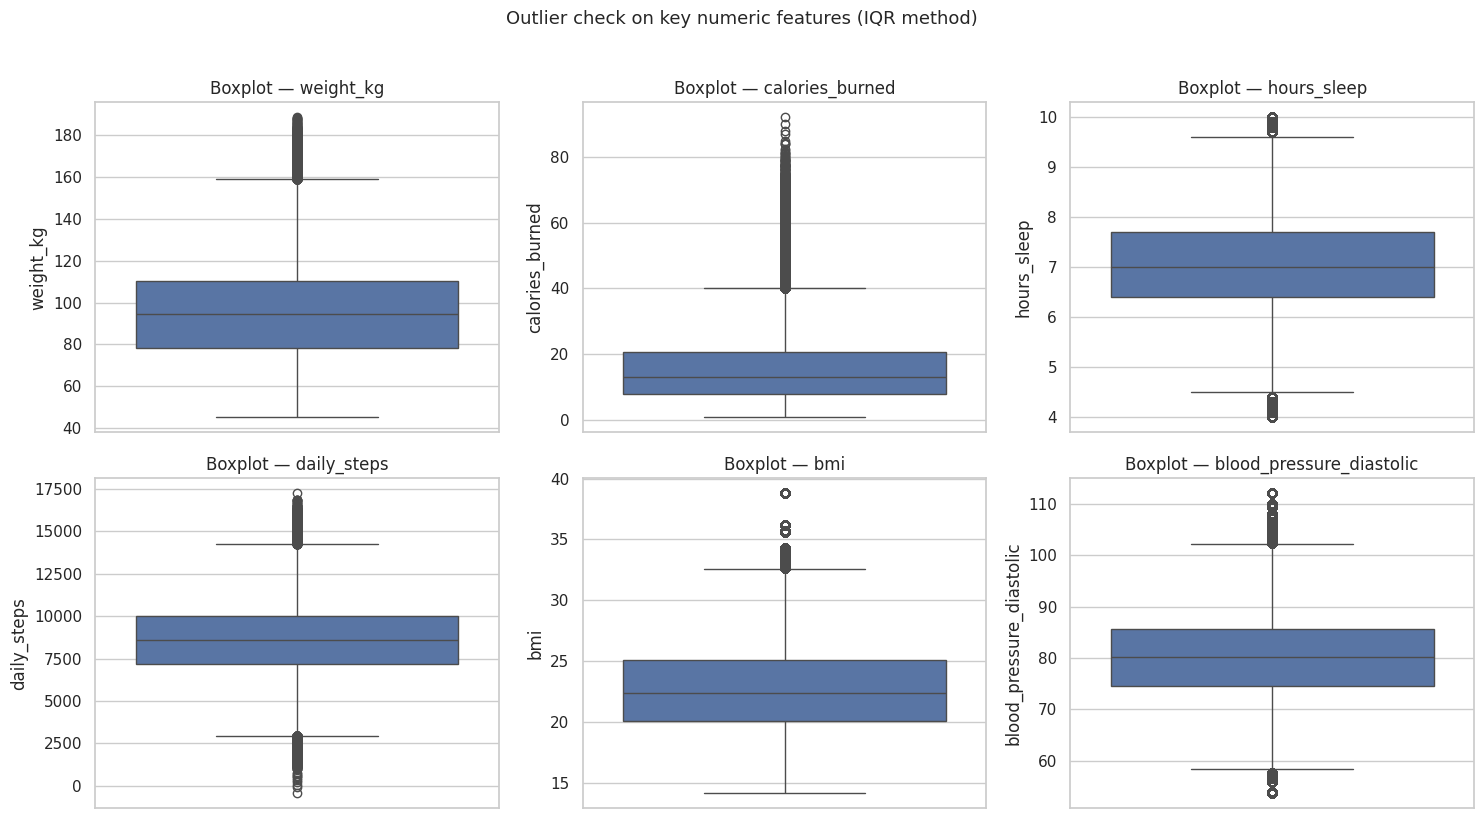

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), ["weight_kg","calories_burned","hours_sleep","daily_steps","bmi","blood_pressure_diastolic"]):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot — {c}")
fig.suptitle("Outlier check on key numeric features (IQR method)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/outlier_boxplots.png", bbox_inches="tight")
plt.show()

In [12]:
# A physically impossible value: daily_steps cannot be negative.
print("Rows with negative daily_steps:", (df["daily_steps"] < 0).sum())
df[df["daily_steps"] < 0][["participant_id","date","daily_steps"]]

Rows with negative daily_steps: 2


,participant_id,date,daily_steps
207781,905,2024-10-01,-419
360838,1573,2024-10-14,-81


In [13]:
# Decision: clip the (very rare) negative step counts to 0 rather than dropping the rows,
# since every other field in those records is valid and informative.
df["daily_steps"] = df["daily_steps"].clip(lower=0)
print("Remaining negative daily_steps:", (df["daily_steps"] < 0).sum())

Remaining negative daily_steps: 0


**Decision summary for outliers:** Every column except `daily_steps` shows between 0% and 2.5% of points flagged by the standard 1.5×IQR rule (e.g. `calories_burned` 2.5%, `blood_pressure_diastolic` 0.9%). Given the large, biologically diverse population (3,000 adults aged 18–64 doing 10 different activity types at 3 intensities), these flagged points sit within physiologically plausible ranges (e.g. blood pressure up to ~150/112, heart rate up to 206 bpm during high-intensity exercise) — they look like genuine biological variation, not measurement errors, so **we keep them rather than removing or capping them**. The one true data-quality issue found was **two rows with negative `daily_steps`** (an impossible value), which we corrected by clipping to 0.

### 3.5 Unnecessary Columns

In [14]:
# participant_id is not a predictive feature (it is an arbitrary identifier), but we deliberately
# KEEP it in the working dataframe — it is required later to perform a participant-level train/test
# split that avoids data leakage (Section 7). It will be excluded from the model's feature matrix
# directly, not dropped from df.
print("participant_id is retained for grouping purposes only — excluded explicitly from X in Section 7.")
df.shape

participant_id is retained for grouping purposes only — excluded explicitly from X in Section 7.


(687701, 22)

## 4. Exploratory Data Analysis (EDA)

Use descriptive statistics and visual exploration to understand distributions, relationships, trends, and possible issues.